## Day 4 - Time Series Preparation for Forecasting

## Create Daily Sales Time Series

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

df = pd.read_csv('../data/clean_retail.csv', parse_dates=['InvoiceDate'])

# Aggregate to daily total revenue
daily = df.groupby(df['InvoiceDate'].dt.date)['TotalRevenue'].sum().reset_index()
daily.columns = ['Date', 'Revenue']
daily['Date'] = pd.to_datetime(daily['Date'])
daily = daily.sort_values('Date').set_index('Date')

# Fill missing dates with 0 (some days might have no sales)
daily = daily.asfreq('D', fill_value=0)

print(daily.head(10))
print(f"Total days: {len(daily)}")

             Revenue
Date                
2009-12-01  44048.69
2009-12-02  52941.99
2009-12-03  67479.08
2009-12-04  34064.41
2009-12-05   9803.05
2009-12-06  24580.72
2009-12-07  33169.63
2009-12-08  44804.34
2009-12-09  31113.60
2009-12-10  38806.36
Total days: 739


## Plot the Time Series

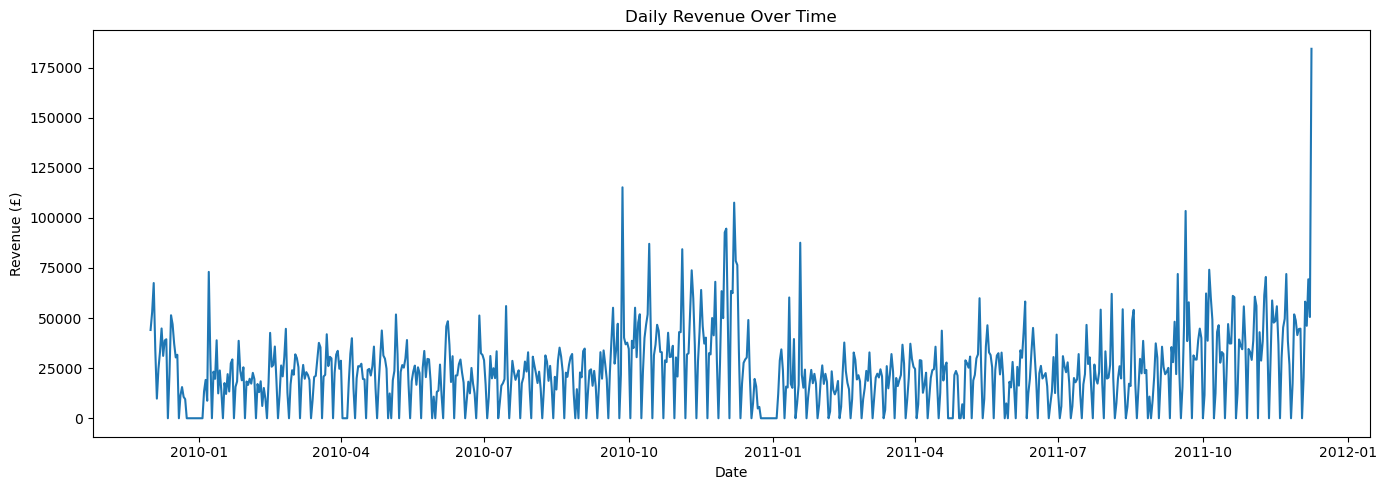

In [2]:
plt.figure(figsize=(14,5))
plt.plot(daily.index, daily['Revenue'])
plt.title('Daily Revenue Over Time')
plt.xlabel('Date')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.savefig('Day4_timeseries.png')
plt.show()
# You'll see spikes around Christmas (November-December peak)

## Stationarity Test (ADF Test)

In [5]:
def adf_test(series, name=''):
    result = adfuller(series.dropna())
    print(f"\nADF Test for {name}")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value:       {result[1]:.4f}")
    print(f"Critical Values: {result[4]}")
    if result[1] < 0.05:
        print("Stationary (p < 0.05) - ready for modelling")
    else:
        print("Non-stationary (p >= 0.05) - needs differencing")

adf_test(daily['Revenue'], 'Daily Revenue')


ADF Test for Daily Revenue
ADF Statistic: -2.1148
p-value:       0.2386
Critical Values: {'1%': np.float64(-3.439490435810785), '5%': np.float64(-2.8655738086413374), '10%': np.float64(-2.568918067209286)}
Non-stationary (p >= 0.05) - needs differencing


## Make Data Stationary

In [6]:
# First-order differencing: subtract yesterday from today
daily['Revenue_diff'] = daily['Revenue'].diff()

adf_test(daily['Revenue_diff'].dropna(), 'Differenced Revenue')
# Usually becomes stationary after 1 differencing


ADF Test for Differenced Revenue
ADF Statistic: -8.5888
p-value:       0.0000
Critical Values: {'1%': np.float64(-3.439490435810785), '5%': np.float64(-2.8655738086413374), '10%': np.float64(-2.568918067209286)}
Stationary (p < 0.05) - ready for modelling


## Time Series Decomposition

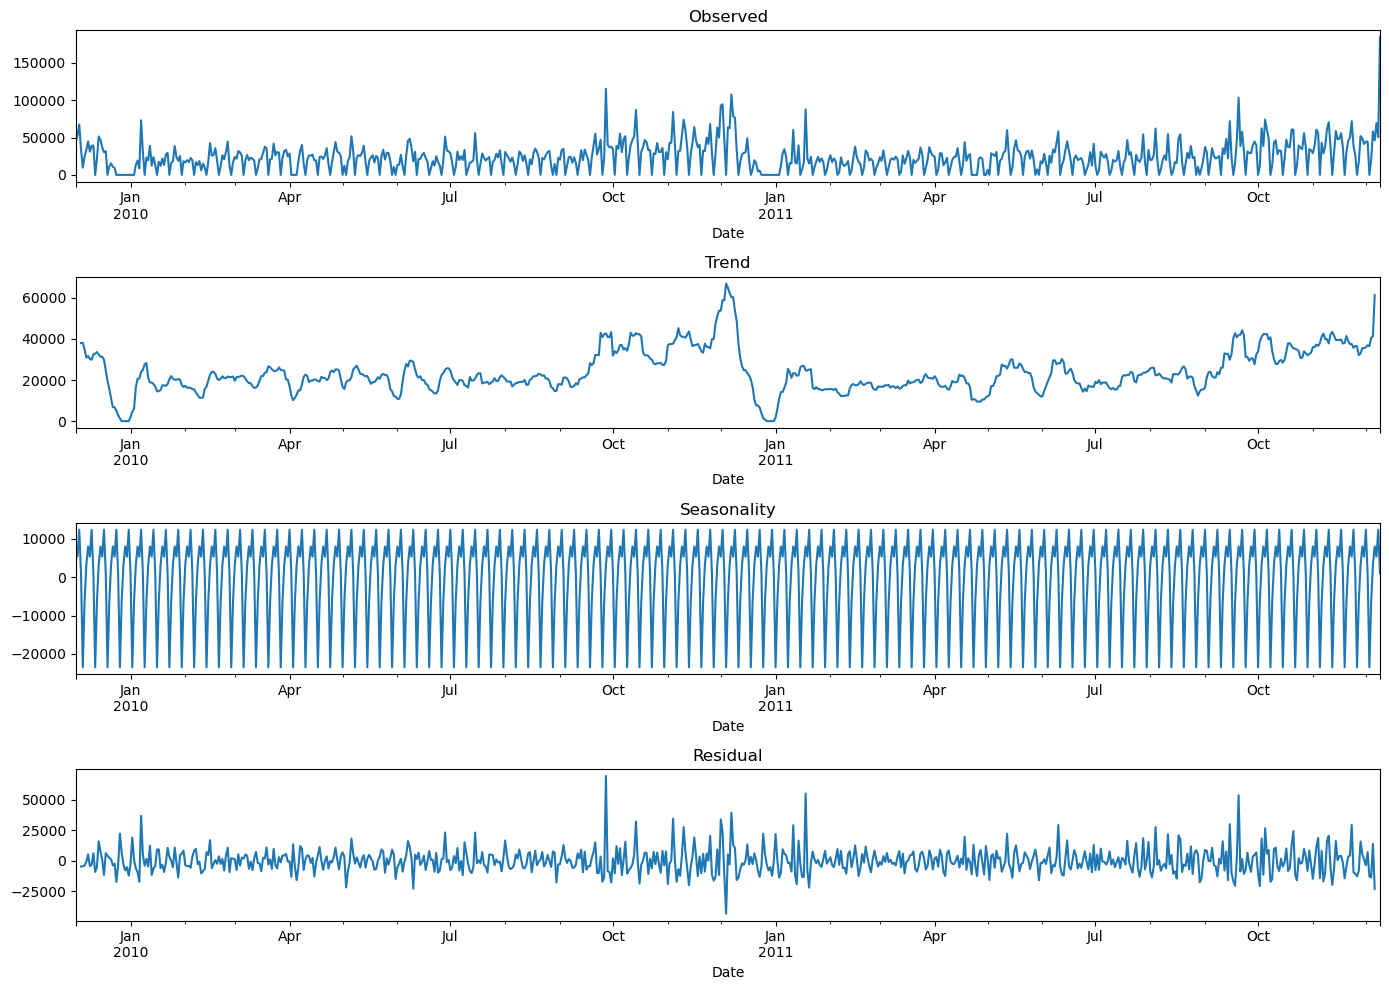

In [7]:
# Decompose — period=7 means weekly seasonality
decomposition = seasonal_decompose(daily['Revenue'], model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomposition.observed.plot(ax=axes[0], title='Observed')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonality')
decomposition.resid.plot(ax=axes[3], title='Residual')
plt.tight_layout()
plt.savefig('Day4_decomposition.png')
plt.show()

##  Prepare Prophet-Format Data

In [9]:
# Prophet requires columns named 'ds' (date) and 'y' (value)
prophet_df = daily.reset_index().rename(columns={'Date': 'ds', 'Revenue': 'y'})
prophet_df = prophet_df[['ds', 'y']]
prophet_df.to_csv('../data/prophet_ready.csv', index=False)
print(prophet_df.head())
print(f"Shape: {prophet_df.shape}")

          ds         y
0 2009-12-01  44048.69
1 2009-12-02  52941.99
2 2009-12-03  67479.08
3 2009-12-04  34064.41
4 2009-12-05   9803.05
Shape: (739, 2)
